# IV time-series diagnostic — RELIANCE / PNB / HDFCBANK

Four overlapping IV time series **plus the spot price** for each of three
stocks over the last ~6 months, with vertical markers at every monthly
expiry inside the window and **grey-shaded regions covering days the
earnings filter would block** (per `PORTFOLIO_MEMOIR.md` §17.5).

**IV series (top subplot):**

- **A** — front-month ATM IV (raw, includes 1-DTE blowups)
- **B** — 30-day constant-maturity IV, NO near-expiry exclusion
- **C** — 30-day CMI with 7-DTE exclusion (CBOE-VIX-style)
- **D** — trailing 252-TD IVP of series C (right axis, 0–100)

**Spot close (bottom subplot)** — the cash equity price for the underlying.

**Grey regions** — for each Financial Results event in the symbol's NSE
corporate-events feed, the cycle that catches the event is shaded. A trade
entered inside a grey region would (by the §17.5 filter) be skipped because
the event lands in `[entry_date, exit_date + 1d]`. Useful for visually
checking which IV spikes line up with earnings.

Forward-based Black-76 inversion via put-call parity. Formulas follow
[`DESIGN/PORTFOLIO_MEMOIR.md` §2.2](../DESIGN/PORTFOLIO_MEMOIR.md).


In [1]:
%matplotlib inline
from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm

# Resolve repo root — works whether the notebook is opened from repo root
# or from scripts/.
REPO = Path.cwd()
if REPO.name == "scripts":
    REPO = REPO.parent

BHAVCOPY_DIR = REPO / "data" / "cache" / "bhavcopy_fo"
SPOT_DIR = REPO / "data" / "cache" / "spot"
EVENTS_CSV = REPO / "CF-Event-equities-06-09-2023-to-04-06-2026.csv"


## Knobs

Edit these inline to re-run the notebook against different symbols, windows,
or constants. Defaults match `PORTFOLIO_MEMOIR.md` §2.2 + §17.5.


In [2]:
RISK_FREE_RATE = 0.065              # ~6.5% Indian short-end
NEAR_EXPIRY_EXCLUSION_DAYS = 7      # CBOE VIX practice (skip front when DTE < 7)
TARGET_DTE = 30                     # constant-maturity target in calendar days
IVP_LOOKBACK_TD = 252               # trailing trading-day window for IVP rank

SYMBOLS = ["RELIANCE", "PNB", "HDFCBANK"]
MONTHS_WINDOW = 6

# Earnings filter — shade-only flag (the visualization always shades; the
# memoir's §17.5 trade-side filter is the operational use; here we just
# overlay the would-be-blocked regions for visual inspection).
EARNINGS_FILTER_ON = True


## Data loaders

Date-indexed spot closes from `data/cache/spot/{SYMBOL}/{YYYY}.parquet`, plus
per-day F&O bhavcopy slices (OPTSTK only) from `data/cache/bhavcopy_fo/`.


In [3]:
def load_spot_closes(symbol: str) -> pd.Series:
    """Date-indexed close prices across all available years for one symbol."""
    files = sorted((SPOT_DIR / symbol).glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"no spot cache for {symbol} at {SPOT_DIR / symbol}")
    frames = [pd.read_parquet(f) for f in files]
    df = pd.concat(frames, ignore_index=True)
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df = df.drop_duplicates(subset="date").set_index("date").sort_index()
    return df["close"].astype(float)


def load_bhavcopy_for_date(d: pd.Timestamp) -> pd.DataFrame | None:
    """OPTSTK-only slice of the F&O bhavcopy for a single trading day,
    or None if the file doesn't exist (holiday / weekend)."""
    path = BHAVCOPY_DIR / f"{d.strftime('%Y%m%d')}.parquet"
    if not path.exists():
        return None
    df = pd.read_parquet(path)
    df = df[df["instrument"] == "OPTSTK"].copy()
    df["expiry"] = pd.to_datetime(df["expiry"]).dt.normalize()
    df["close"] = df["close"].astype(float)
    return df


def trading_day_index() -> pd.DatetimeIndex:
    """All trading days present in the bhavcopy_fo cache."""
    files = sorted(BHAVCOPY_DIR.glob("*.parquet"))
    dates = [pd.to_datetime(f.stem, format="%Y%m%d") for f in files]
    return pd.DatetimeIndex(sorted(dates))


## Earnings calendar — load + per-symbol block regions

Source: NSE Corporate Events CSV at the repo root
(`CF-Event-equities-06-09-2023-to-04-06-2026.csv`), per
`PORTFOLIO_MEMOIR.md` §17.

The CSV's `DATE` column is the **board-meeting date** (results-announcement
day). The §17.5 filter blocks a trade if any Financial Results event lands
in `[entry_date, exit_date + 1d]`. Translated to the visualization:

- For each Financial Results event `E` for the symbol, identify the
  monthly expiry `M` such that `M ≥ E` (the cycle that catches the event).
- Identify the prior monthly expiry `P_prev` (the start of that cycle).
- Shade `[P_prev + 1 day, M + 1 day]` grey. Any candidate entry day in
  that region would catch the event under the §17.5 filter and be
  skipped.

Symbols not present in the events CSV degrade gracefully (no shading).


In [4]:
def load_earnings_events(path: Path = EVENTS_CSV) -> pd.DataFrame:
    """Load NSE Corporate Events CSV, normalise whitespace + dates,
    filter to Financial Results only. Returns DataFrame with columns
    ``SYMBOL`` (str, stripped), ``PURPOSE`` (str), ``DATE`` (datetime)."""
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df["SYMBOL"] = df["SYMBOL"].astype(str).str.strip()
    df["PURPOSE"] = df["PURPOSE"].astype(str).str.strip()
    df["DATE"] = pd.to_datetime(
        df["DATE"].astype(str).str.strip(), format="%d-%b-%Y", errors="coerce",
    )
    df = df.dropna(subset=["DATE"])
    return df[df["PURPOSE"].str.contains("Financial Results", na=False)].copy()


def earnings_block_regions(
    symbol: str,
    events_df: pd.DataFrame,
    monthly_expiries: list[pd.Timestamp],
    window_start: pd.Timestamp,
    window_end: pd.Timestamp,
) -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    """For each Financial Results event for ``symbol`` that touches the
    plot window, return the (start, end) calendar-date range to shade.

    Block region for event ``E``:
      - ``M`` = first monthly expiry such that ``M >= E`` (cycle catching ``E``)
      - ``P_prev`` = prior monthly expiry (or ``M - 30 days`` if none)
      - Region = ``[P_prev + 1 day, M + 1 day]``

    Reflects PORTFOLIO_MEMOIR §17.5: a trade entered after ``P_prev`` and
    held to ``M`` has ``E ∈ [entry_date, exit_date + 1d]``."""
    sym_events = events_df[events_df["SYMBOL"] == symbol]
    if sym_events.empty or not monthly_expiries:
        return []
    expiries_sorted = sorted(monthly_expiries)
    regions = []
    for E in sym_events["DATE"]:
        # M = first expiry >= E
        M = next((x for x in expiries_sorted if x >= E), None)
        if M is None:
            continue
        # P_prev = last expiry before M (else fall back to M - 30 days)
        idx = expiries_sorted.index(M)
        P_prev = (
            expiries_sorted[idx - 1] if idx > 0
            else M - pd.Timedelta(days=30)
        )
        start = P_prev + pd.Timedelta(days=1)
        end = M + pd.Timedelta(days=1)
        # Clip to plot window — skip events whose cycle falls entirely outside.
        if end < window_start or start > window_end:
            continue
        regions.append((max(start, window_start), min(end, window_end)))
    return regions


## Black-76 IV inversion

Forward-based Black-76 (not Black-Scholes on spot+rate) — absorbs dividends
and borrow costs via the synthetic forward extracted from put-call parity at
the ATM strike. Numerical inversion via `scipy.optimize.brentq` on
`call_price(σ) − market_price`, bracketed to `[1e-4, 5.0]`.


In [5]:
def bs76_call_price(F: float, K: float, T: float, sigma: float, r: float) -> float:
    """Black-76 call price on a forward F."""
    if T <= 0.0 or sigma <= 0.0:
        return max(0.0, np.exp(-r * T) * (F - K))
    sqrtT = np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return float(np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2)))


def extract_forward_via_parity(
    call_px: float, put_px: float, K: float, T: float, r: float,
) -> float:
    """Synthetic forward from put-call parity: F = K + (C − P)·exp(r·T)."""
    return float(K + (call_px - put_px) * np.exp(r * T))


def implied_vol_black76(
    call_px: float, F: float, K: float, T: float, r: float,
) -> float | None:
    """Brentq IV inversion. Returns None on no-arbitrage / unbracketable input."""
    if T <= 0.0 or call_px <= 0.0 or F <= 0.0 or K <= 0.0:
        return None
    intrinsic = max(0.0, np.exp(-r * T) * (F - K))
    if call_px <= intrinsic + 1e-8:
        return None
    if call_px >= np.exp(-r * T) * F:
        return None
    def err(sigma: float) -> float:
        return bs76_call_price(F, K, T, sigma, r) - call_px
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            return float(brentq(err, 1e-4, 5.0, xtol=1e-6, maxiter=64))
    except (ValueError, RuntimeError):
        return None


## Per-(symbol, date, expiry) ATM IV

For each available monthly expiry on a given trading day, find the ATM
strike (closest listed strike to spot with both CE+PE having non-zero
close), extract the forward via parity, and invert Black-76.


In [6]:
@dataclass
class ExpiryIV:
    expiry: pd.Timestamp
    dte: int
    atm_strike: float
    iv: float


def atm_strike(chain: pd.DataFrame, spot: float) -> float | None:
    ce = chain[chain["option_type"] == "CE"].set_index("strike")["close"]
    pe = chain[chain["option_type"] == "PE"].set_index("strike")["close"]
    common = ce.index.intersection(pe.index)
    if len(common) == 0:
        return None
    valid = [k for k in common if ce[k] > 0 and pe[k] > 0]
    if not valid:
        return None
    arr = np.asarray(valid, dtype=float)
    return float(arr[np.argmin(np.abs(arr - spot))])


def iv_per_expiry(
    symbol: str, trade_date: pd.Timestamp, spot: float, bhav: pd.DataFrame,
) -> list[ExpiryIV]:
    sym_chain = bhav[bhav["symbol"] == symbol]
    if sym_chain.empty:
        return []
    out: list[ExpiryIV] = []
    for expiry, chain in sym_chain.groupby("expiry"):
        dte = (expiry.normalize() - trade_date.normalize()).days
        if dte <= 0:
            continue
        T = dte / 365.0
        k_atm = atm_strike(chain, spot)
        if k_atm is None:
            continue
        c = float(chain[(chain["option_type"] == "CE") & (chain["strike"] == k_atm)]["close"].iloc[0])
        p = float(chain[(chain["option_type"] == "PE") & (chain["strike"] == k_atm)]["close"].iloc[0])
        F = extract_forward_via_parity(c, p, k_atm, T, RISK_FREE_RATE)
        iv = implied_vol_black76(c, F, k_atm, T, RISK_FREE_RATE)
        if iv is None or not np.isfinite(iv):
            continue
        out.append(ExpiryIV(expiry=expiry, dte=dte, atm_strike=k_atm, iv=iv))
    out.sort(key=lambda e: e.dte)
    return out


## Series A / B / C / D

- **A** Front-month ATM IV — closest-expiry pick, no filtering.
- **B/C** 30-day constant-maturity IV via variance-space interpolation between
  the two expiries bracketing 30 DTE. `exclude_lt_dte=0` for B, `=7` for C.
- **D** Trailing-`IVP_LOOKBACK_TD` percentile rank of series C, 0–100.


In [7]:
def front_month_iv(per_expiry: list[ExpiryIV]) -> float | None:
    if not per_expiry:
        return None
    return per_expiry[0].iv


def constant_maturity_30d(
    per_expiry: list[ExpiryIV], exclude_lt_dte: int = 0,
) -> float | None:
    survivors = [e for e in per_expiry if e.dte >= exclude_lt_dte]
    if len(survivors) < 2:
        return None
    near = [e for e in survivors if e.dte <= TARGET_DTE]
    far = [e for e in survivors if e.dte > TARGET_DTE]
    if near and far:
        e_near = max(near, key=lambda e: e.dte)
        e_far = min(far, key=lambda e: e.dte)
    else:
        sorted_by_dist = sorted(survivors, key=lambda e: abs(e.dte - TARGET_DTE))
        e_near, e_far = sorted_by_dist[0], sorted_by_dist[1]
        if e_near.dte > e_far.dte:
            e_near, e_far = e_far, e_near
    if e_near.dte == e_far.dte:
        return float(np.sqrt(0.5 * (e_near.iv ** 2 + e_far.iv ** 2)))
    var_near = e_near.iv ** 2
    var_far = e_far.iv ** 2
    span = e_far.dte - e_near.dte
    var_30 = (
        var_near * (e_far.dte - TARGET_DTE) / span
        + var_far * (TARGET_DTE - e_near.dte) / span
    )
    return float(np.sqrt(max(var_30, 0.0)))


def trailing_ivp(series: pd.Series, lookback: int = IVP_LOOKBACK_TD) -> pd.Series:
    def pct_rank(window: np.ndarray) -> float:
        if len(window) < lookback:
            return np.nan
        today = window[-1]
        return float(100.0 * (np.sum(window <= today) - 1) / (len(window) - 1))
    return series.rolling(lookback, min_periods=lookback).apply(pct_rank, raw=True)


## Per-symbol full-history computation


In [8]:
def compute_iv_history(
    symbol: str, start: pd.Timestamp, end: pd.Timestamp,
) -> pd.DataFrame:
    spot_series = load_spot_closes(symbol)
    rows: list[dict] = []
    day_index = trading_day_index()
    day_index = day_index[(day_index >= start) & (day_index <= end)]
    for d in day_index:
        if d not in spot_series.index:
            continue
        spot = float(spot_series.loc[d])
        bhav = load_bhavcopy_for_date(d)
        if bhav is None or bhav.empty:
            continue
        per_exp = iv_per_expiry(symbol, d, spot, bhav)
        if not per_exp:
            continue
        rows.append({
            "trade_date": d,
            "iv_front": front_month_iv(per_exp),
            "iv_cmi30_raw": constant_maturity_30d(per_exp, exclude_lt_dte=0),
            "iv_cmi30_excl": constant_maturity_30d(
                per_exp, exclude_lt_dte=NEAR_EXPIRY_EXCLUSION_DAYS,
            ),
            "expiries": tuple(sorted({e.expiry for e in per_exp})),
        })
    return pd.DataFrame(rows).set_index("trade_date").sort_index()


def monthly_expiry_dates(
    history: pd.DataFrame, window_start, window_end,
) -> list[pd.Timestamp]:
    all_expiries: set[pd.Timestamp] = set()
    for s in history["expiries"]:
        for e in s:
            all_expiries.add(e)
    return sorted(
        e for e in all_expiries if window_start <= e <= window_end
    )


def all_monthly_expiries(history: pd.DataFrame) -> list[pd.Timestamp]:
    """Every monthly expiry observed in any day's chain — used for the
    earnings block-region calculation, which needs the prior expiry that
    may sit BEFORE the plot window."""
    all_expiries: set[pd.Timestamp] = set()
    for s in history["expiries"]:
        for e in s:
            all_expiries.add(e)
    return sorted(all_expiries)


## Plotting — two-row subplot (IV stack + spot) + earnings shading

The IV stack (A/B/C/D) lives on the top subplot; the cash spot close lives on
the bottom subplot. Both share the x-axis, both carry vertical dashed lines
at every monthly expiry inside the window, and **both carry grey-shaded
regions for days the earnings filter would block** (per §17.5).


In [9]:
def plot_symbol(
    symbol: str, history: pd.DataFrame, spot_series: pd.Series,
    window_start: pd.Timestamp, window_end: pd.Timestamp,
    earnings_events: pd.DataFrame | None = None,
):
    """Render the four IV series + spot price + earnings-block shading."""
    history = history.copy()
    history["ivp_cmi30_excl"] = trailing_ivp(history["iv_cmi30_excl"])

    in_iv = history.loc[
        (history.index >= window_start) & (history.index <= window_end)
    ]
    in_spot = spot_series.loc[
        (spot_series.index >= window_start) & (spot_series.index <= window_end)
    ]

    fig, (ax_iv, ax_spot) = plt.subplots(
        2, 1, figsize=(13, 9), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.0], "hspace": 0.08},
    )

    # --- Earnings block regions (drawn FIRST so axvspan sits behind lines)
    block_regions: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    if earnings_events is not None and EARNINGS_FILTER_ON:
        all_expiries = all_monthly_expiries(history)
        block_regions = earnings_block_regions(
            symbol, earnings_events, all_expiries, window_start, window_end,
        )
        for i, (start, end) in enumerate(block_regions):
            # Label only the first span so the legend has one entry, not N.
            label = (
                "earnings-filter blocked cycle"
                if i == 0 and EARNINGS_FILTER_ON else None
            )
            ax_iv.axvspan(
                start, end, color="grey", alpha=0.18, linewidth=0, label=label,
            )
            ax_spot.axvspan(
                start, end, color="grey", alpha=0.18, linewidth=0,
            )

    # --- Top: A / B / C on left y-axis (IV %)
    ax_iv.plot(
        in_iv.index, in_iv["iv_front"] * 100,
        label="A · front-month ATM IV (naive)",
        color="#d62728", linewidth=1.0, alpha=0.55,
    )
    ax_iv.plot(
        in_iv.index, in_iv["iv_cmi30_raw"] * 100,
        label="B · 30D CMI (no near-expiry exclusion)",
        color="#ff7f0e", linewidth=1.4, alpha=0.85,
    )
    ax_iv.plot(
        in_iv.index, in_iv["iv_cmi30_excl"] * 100,
        label=f"C · 30D CMI (skip front if DTE < {NEAR_EXPIRY_EXCLUSION_DAYS})",
        color="#1f77b4", linewidth=1.8,
    )
    ax_iv.set_ylabel("Annualised IV (%)", fontsize=11)
    ax_iv.grid(True, alpha=0.25)

    # --- Top right: Series D (IVP) on twin axis
    ax_ivp = ax_iv.twinx()
    ax_ivp.plot(
        in_iv.index, in_iv["ivp_cmi30_excl"],
        label=f"D · trailing-{IVP_LOOKBACK_TD}-TD IVP of C",
        color="#2ca02c", linewidth=1.3, linestyle="--",
    )
    ax_ivp.set_ylabel("IVP (percentile, 0–100)", fontsize=11)
    ax_ivp.set_ylim(0, 100)
    ax_ivp.axhline(50, color="#2ca02c", linestyle=":", linewidth=0.5, alpha=0.4)

    # --- Bottom: spot close
    ax_spot.plot(
        in_spot.index, in_spot.values,
        label=f"{symbol} spot close",
        color="#9467bd", linewidth=1.4,
    )
    ax_spot.set_ylabel(f"{symbol} close (₹)", fontsize=11)
    ax_spot.grid(True, alpha=0.25)
    ax_spot.set_xlabel("Trade date", fontsize=11)
    ax_spot.xaxis.set_major_locator(mdates.MonthLocator())
    ax_spot.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    # --- Vertical expiry markers on BOTH subplots
    expiry_dates = monthly_expiry_dates(history, window_start, window_end)
    for ed in expiry_dates:
        ax_iv.axvline(ed, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
        ax_spot.axvline(ed, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
    if expiry_dates:
        ax_iv.axvline(
            expiry_dates[0], color="grey", linestyle=":", linewidth=0.8,
            alpha=0.6, label="monthly expiry",
        )

    # --- Combined legend below both subplots
    h1, l1 = ax_iv.get_legend_handles_labels()
    h2, l2 = ax_ivp.get_legend_handles_labels()
    h3, l3 = ax_spot.get_legend_handles_labels()
    fig.legend(
        h1 + h2 + h3, l1 + l2 + l3,
        loc="upper center", bbox_to_anchor=(0.5, 0.045),
        ncol=3, frameon=False, fontsize=9,
    )

    n_blocked = len(block_regions)
    title = (
        f"ATM IV diagnostic — {symbol}  "
        f"({window_start.date()} → {window_end.date()})"
    )
    if n_blocked:
        title += f"   ·   {n_blocked} earnings cycle(s) shaded"
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.subplots_adjust(top=0.94, bottom=0.11, left=0.07, right=0.92)
    plt.show()


## Run — compute + render for each symbol

The trailing-252-TD IVP needs a year of IV history before the plot window so
the backfill computation starts ~`IVP_LOOKBACK_TD` trading days before
`window_start`. The earnings CSV is loaded once and reused for all symbols.
Output is rendered inline; rerun the cell to re-plot after changing any knob
above.


bhavcopy range: 2024-03-21 → 2026-05-26
plot window:    2025-11-26 → 2026-05-26
IV history:     2024-10-27 → 2026-05-26  (for trailing-252-TD IVP backfill)
earnings CSV:   24,266 Financial-Results rows loaded (2387 symbols)

=== RELIANCE ===


  IV days computed:     389
  days in plot window:  121
  iv_front        median= 20.2%  p5= 13.4%  p95= 28.2%  min=  8.9%  max= 32.4%
  iv_cmi30_raw    median= 21.6%  p5= 15.0%  p95= 27.3%  min= 14.1%  max= 32.3%
  iv_cmi30_excl   median= 21.2%  p5= 14.9%  p95= 27.3%  min= 13.4%  max= 32.3%
  earnings events:       11 total,  2 touching plot window


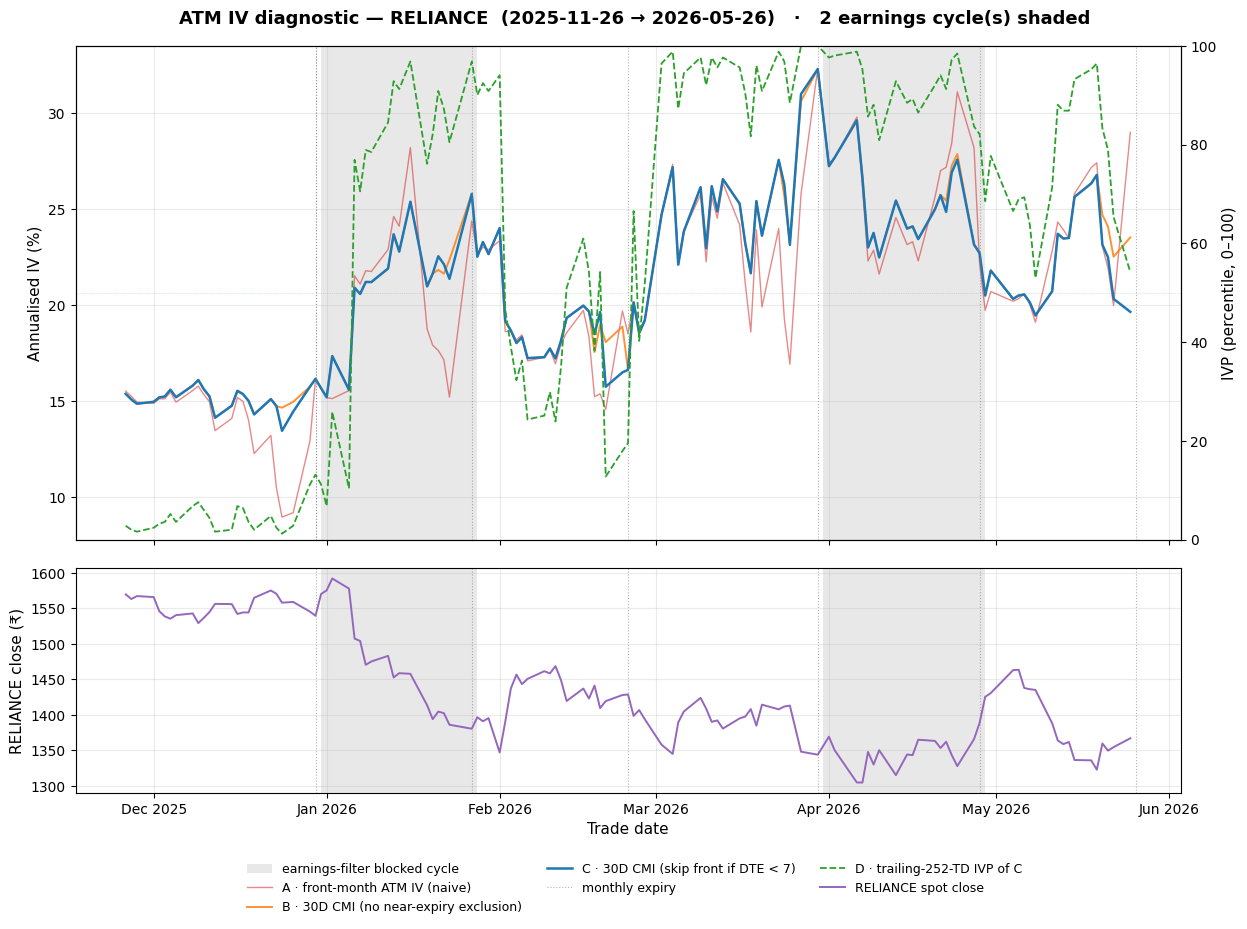


=== PNB ===


  IV days computed:     390
  days in plot window:  122
  iv_front        median= 29.5%  p5= 20.8%  p95= 41.7%  min= 14.7%  max= 47.4%
  iv_cmi30_raw    median= 31.1%  p5= 22.1%  p95= 42.6%  min= 20.6%  max= 57.0%
  iv_cmi30_excl   median= 31.1%  p5= 21.5%  p95= 42.6%  min= 19.2%  max= 57.0%
  earnings events:       11 total,  2 touching plot window


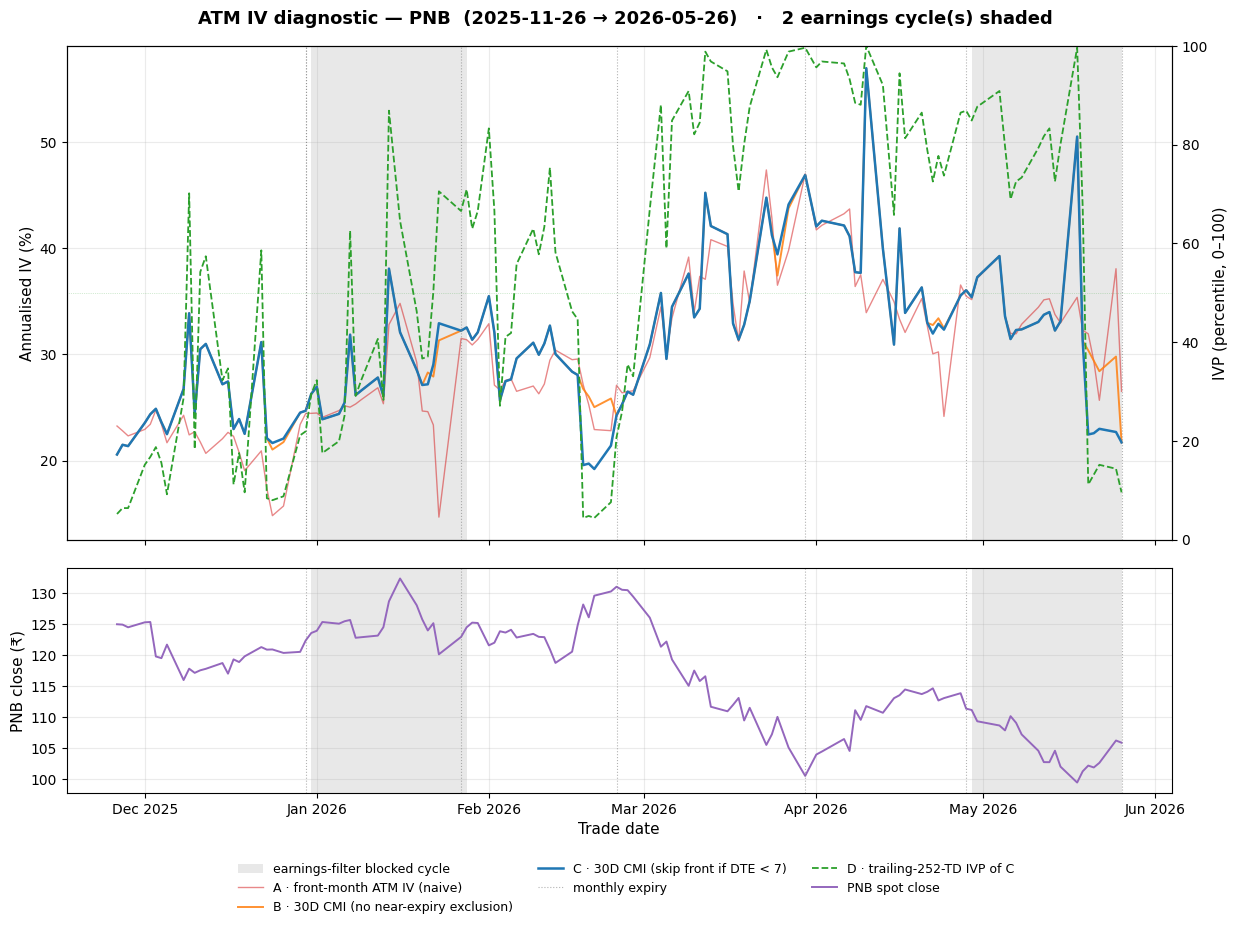


=== HDFCBANK ===


  IV days computed:     389
  days in plot window:  121
  iv_front        median= 20.5%  p5= 14.2%  p95= 32.5%  min= 11.5%  max= 40.4%
  iv_cmi30_raw    median= 20.1%  p5= 14.9%  p95= 33.0%  min= 13.2%  max= 40.0%
  iv_cmi30_excl   median= 20.1%  p5= 14.9%  p95= 33.7%  min= 13.2%  max= 40.0%
  earnings events:       11 total,  2 touching plot window


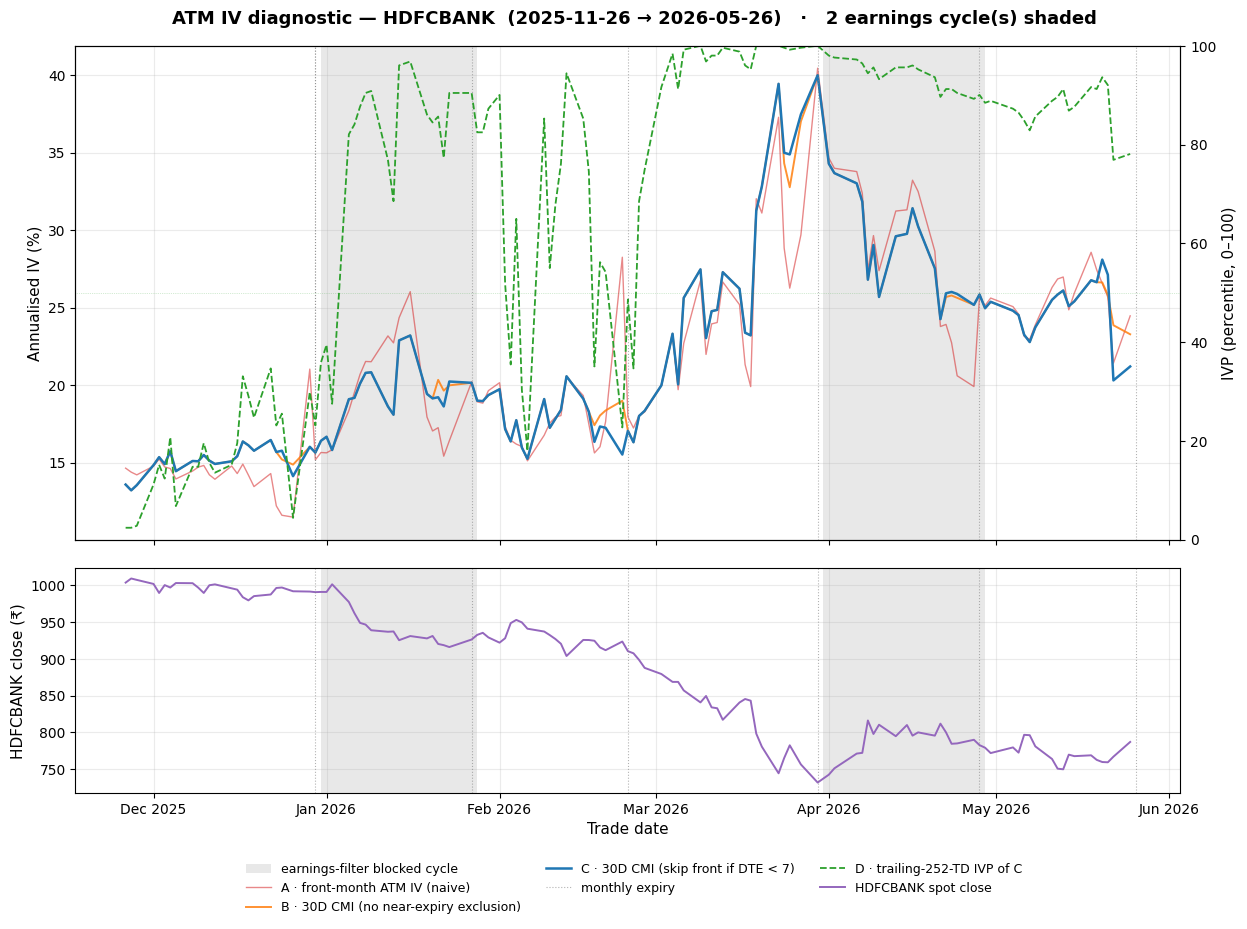

In [10]:
day_index = trading_day_index()
end = day_index.max()
window_start = end - pd.DateOffset(months=MONTHS_WINDOW)

# Backfill the trailing-252-TD IVP buffer: approximate 252 TD as
# 252 * 365/252 = 365 calendar days, with a small cushion.
backfill_calendar_days = int(IVP_LOOKBACK_TD * 365 / 252) + 30
history_start = max(
    day_index.min(),
    window_start - pd.Timedelta(days=backfill_calendar_days),
)

print(f"bhavcopy range: {day_index.min().date()} → {day_index.max().date()}")
print(f"plot window:    {window_start.date()} → {end.date()}")
print(f"IV history:     {history_start.date()} → {end.date()}  "
      f"(for trailing-{IVP_LOOKBACK_TD}-TD IVP backfill)")

# Load earnings events once. If the CSV is missing, plotting still works,
# just without the shading.
events_df: pd.DataFrame | None = None
if EVENTS_CSV.exists():
    events_df = load_earnings_events()
    print(f"earnings CSV:   {len(events_df):,} Financial-Results rows loaded "
          f"({events_df['SYMBOL'].nunique()} symbols)")
else:
    print(f"earnings CSV NOT FOUND at {EVENTS_CSV} — proceeding without shading")
print()

for symbol in SYMBOLS:
    print(f"=== {symbol} ===")
    hist = compute_iv_history(symbol, history_start, end)
    if hist.empty:
        print("  no IV history — skipping")
        continue
    in_window = hist.loc[(hist.index >= window_start) & (hist.index <= end)]
    print(f"  IV days computed:    {len(hist):>4}")
    print(f"  days in plot window: {len(in_window):>4}")
    if len(in_window) > 0:
        for col in ("iv_front", "iv_cmi30_raw", "iv_cmi30_excl"):
            vals = in_window[col].dropna() * 100
            if len(vals):
                print(f"  {col:<14}  median={vals.median():>5.1f}%  "
                      f"p5={vals.quantile(0.05):>5.1f}%  "
                      f"p95={vals.quantile(0.95):>5.1f}%  "
                      f"min={vals.min():>5.1f}%  max={vals.max():>5.1f}%")
    if events_df is not None:
        sym_events = events_df[events_df["SYMBOL"] == symbol]
        in_window_events = sym_events[
            (sym_events["DATE"] >= window_start - pd.Timedelta(days=30))
            & (sym_events["DATE"] <= end)
        ]
        print(f"  earnings events:     {len(sym_events):>4} total, "
              f"{len(in_window_events):>2} touching plot window")
    spot = load_spot_closes(symbol)
    plot_symbol(symbol, hist, spot, window_start, end, earnings_events=events_df)
    print()
